Matplotlib is building the font cache; this may take a moment.


<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          1200 non-null   int64         
 1   customer_id       1200 non-null   int32         
 2   product_id        1200 non-null   int32         
 3   order_date        1200 non-null   datetime64[us]
 4   product_category  1200 non-null   str           
 5   quantity          1200 non-null   int32         
 6   unit_price        1200 non-null   int32         
 7   total_price       1200 non-null   int32         
dtypes: datetime64[us](1), int32(5), int64(1), str(1)
memory usage: 51.7 KB


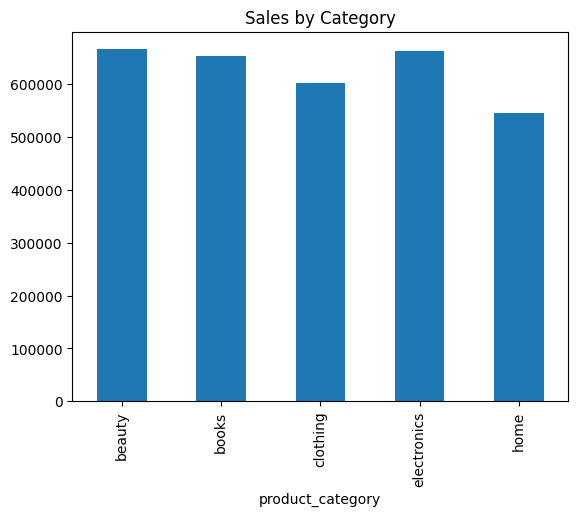

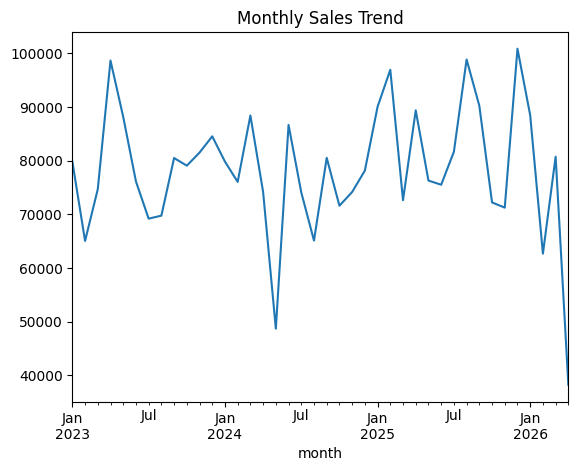

(np.int64(3129620), 1200, np.float64(2608.016666666667))

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
rows = 1200

data = {
    "order_id": range(1, rows + 1),
    "customer_id": np.random.randint(1000, 2000, rows),
    "product_id": np.random.randint(1, 100, rows),
    "order_date": pd.date_range(start="2023-01-01", periods=rows),
    "product_category": np.random.choice(
        ["Electronics", "Clothing", "Home", "Books", "Beauty"], rows
    ),
    "quantity": np.random.randint(1, 5, rows),
    "unit_price": np.random.randint(100, 2000, rows)
}

df = pd.DataFrame(data)
df["total_price"] = df["quantity"] * df["unit_price"]

df.to_csv("./data/ecommerce_sales.csv", index=False)

df.info()
df.describe()
df.isnull().sum()

df["order_date"] = pd.to_datetime(df["order_date"])

df["product_category"] = df["product_category"].str.lower().str.strip()

df.groupby("product_category")["total_price"].sum().plot(
    kind="bar", title="Sales by Category"
)
plt.show()

df["month"] = df["order_date"].dt.to_period("M")

df.groupby("month")["total_price"].sum().plot(
    title="Monthly Sales Trend"
)
plt.show()

total_sales = df["total_price"].sum()
total_orders = df["order_id"].nunique()
avg_order_value = total_sales / total_orders

total_sales, total_orders, avg_order_value